In [14]:

library(here)

library("zoo")
library("tglkmeans")
library("misha.ext")
library("data.table")
library(tidyverse)
library(tgstat)
library(umap)



link_dir =  paste0(here(),'/')
setwd(here())

source(paste0(link_dir,'code/seq2epi_utils.r'))

source(paste0(link_dir,'code/fig_fun.r'))




In [10]:
cell_mc = readRDS('./data/cell_mc_S9_umap.rds')

mat_f = readRDS('./data//mat_f_S9_umap.rds')
mc_types_col = readRDS('./data//mc_types_col_S9_umap.rds')

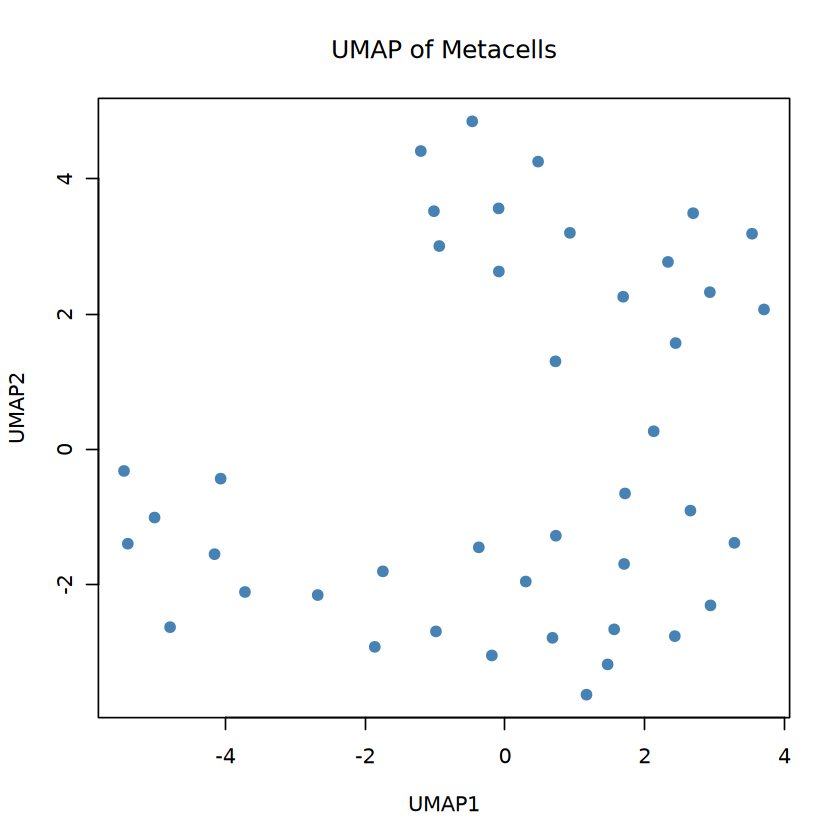

In [11]:
# Optional: scale data (recommended for gene-expression matrices)
set.seed(42)
X = t(mat_f)
X_scaled <- scale(X)

# Run UMAP with default settings
config <- umap.defaults
config$n_neighbors  <- 12#10#12
config$min_dist     <- .96#0.96
config$metric       <- "euclidean"

umap_res <- umap(X_scaled, config = config)
#umap_res <- umap(X_scaled)
#umap_res <- umap(t(markers))
# Extract coordinates
coords <- as.data.frame(umap_res$layout)
colnames(coords) <- c("UMAP1", "UMAP2")

# Plot
plot(coords$UMAP1, coords$UMAP2,
     pch=19,
     col="steelblue",
     xlab="UMAP1",
     ylab="UMAP2",
     main="UMAP of Metacells")

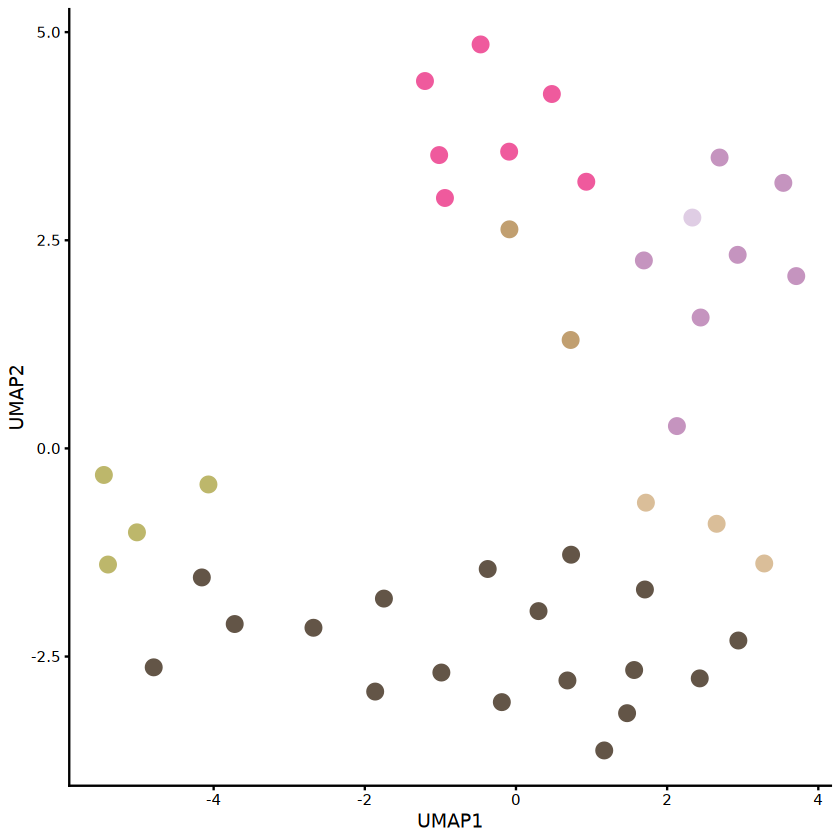

In [12]:
coords = coords %>% rownames_to_column(var = 'mc')

coords$mc = gsub('X','',coords$mc)

plot = merge(coords,mc_types_col,by.x = 'mc',by.y='metacell')

plot %>% ggplot(aes(x = UMAP1, y = UMAP2, col = color.x)) + geom_point(size = 4)+theme_classic()+
scale_color_identity()

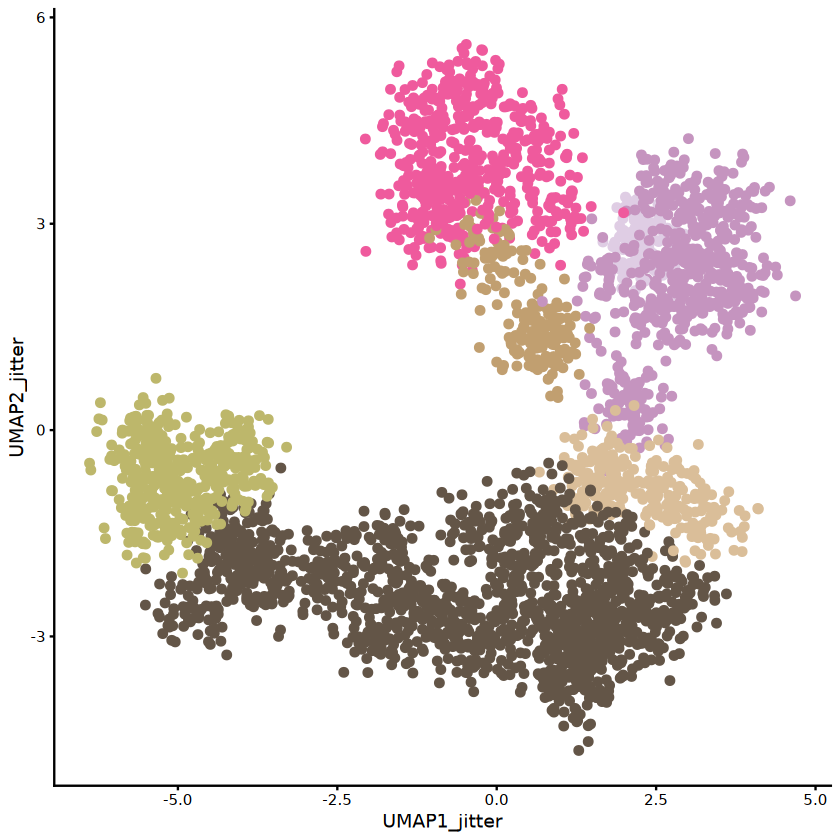

In [13]:
plot_cells = merge(cell_mc,plot,by.x='mc.mc',by.y = 'mc')

set.seed(42)
noise_scale <- 0.33

plot_cells$UMAP1_jitter <- plot_cells$UMAP1 + rnorm(nrow(plot_cells), 0, noise_scale)
plot_cells$UMAP2_jitter <- plot_cells$UMAP2 + rnorm(nrow(plot_cells), 0, noise_scale)

plot_cells %>% ggplot(aes(x =UMAP1_jitter, y = UMAP2_jitter, col = color.x)) + geom_point(size = 2)+theme_classic()+
scale_color_identity()